# Predictive Insight Engine

## House Price Prediction Project

This notebook follows the assignment part by part and uses the given real estate dataset for all practical tasks.

## Part A: Conceptual Understanding

### 1. What are Supervised Learning Algorithms?
Supervised learning algorithms learn from labeled data, where the input features and correct output are already known. The model studies the relationship between them and then predicts the output for new data. In this project, house features are inputs and house price is the output.

### 2. Difference between Regression Algorithms and Classification Algorithms
Regression algorithms predict continuous values such as house price, salary, or temperature. Classification algorithms predict categories such as yes or no, spam or not spam, or approved or rejected. So regression answers "how much" while classification answers "which class."

### 3. Explain Simple Linear Regression
Simple linear regression studies the relationship between one independent variable and one dependent variable. It fits a straight line in the form `y = mx + c`, where `m` is the slope and `c` is the intercept. In this notebook, I use house area to predict house price.

### 4. Assumptions of Linear Regression
The main assumptions are linearity, independent observations, constant error variance, roughly normal residuals, and low multicollinearity in multi-feature models. If these assumptions are badly violated, the model becomes less reliable. So we check the residual plots instead of trusting the equation blindly.

### 5. What is Bias-Variance Trade-Off?
Bias is error caused by an overly simple model, while variance is error caused by a model that reacts too much to the training data. A good model balances both so it performs well on new data. Very simple models usually underfit, and very complex models can overfit.

### 6. Explain Overfitting and Underfitting with examples
Underfitting happens when a model is too simple and misses the real pattern, like predicting house price using only a weak rule. Overfitting happens when a model learns noise from training data and performs poorly on new data. For example, a very complex polynomial may fit the training points closely but fail on the test set.

## Part B: Dataset Understanding and Preparation

In [18]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "real_estate_house_price_dataset.csv"
df = pd.read_csv(DATA_PATH)

target = "house_price_inr"
core_features = ["area_sqft", "bedrooms", "bathrooms", "location_score", "age_years"]
all_features = [col for col in df.columns if col not in ["house_id", target]]

def adjusted_r2(r2_value, n_rows, n_features):
    return 1 - ((1 - r2_value) * (n_rows - 1) / (n_rows - n_features - 1))

def regression_metrics(y_true, y_pred, n_features):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2(r2, len(y_true), n_features)
    return {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "Adjusted R2": adj_r2,
    }

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (4200, 12)


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [19]:
independent_variables = all_features
dependent_variable = target

print("Independent variables:")
print(independent_variables)
print("\nDependent variable:")
print(dependent_variable)

Independent variables:
['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago']

Dependent variable:
house_price_inr


,Correlation with house price
house_price_inr,1.000000
area_sqft,0.755434
bedrooms,0.644772
location_score,0.588531
bathrooms,0.527044
age_years,-0.089454


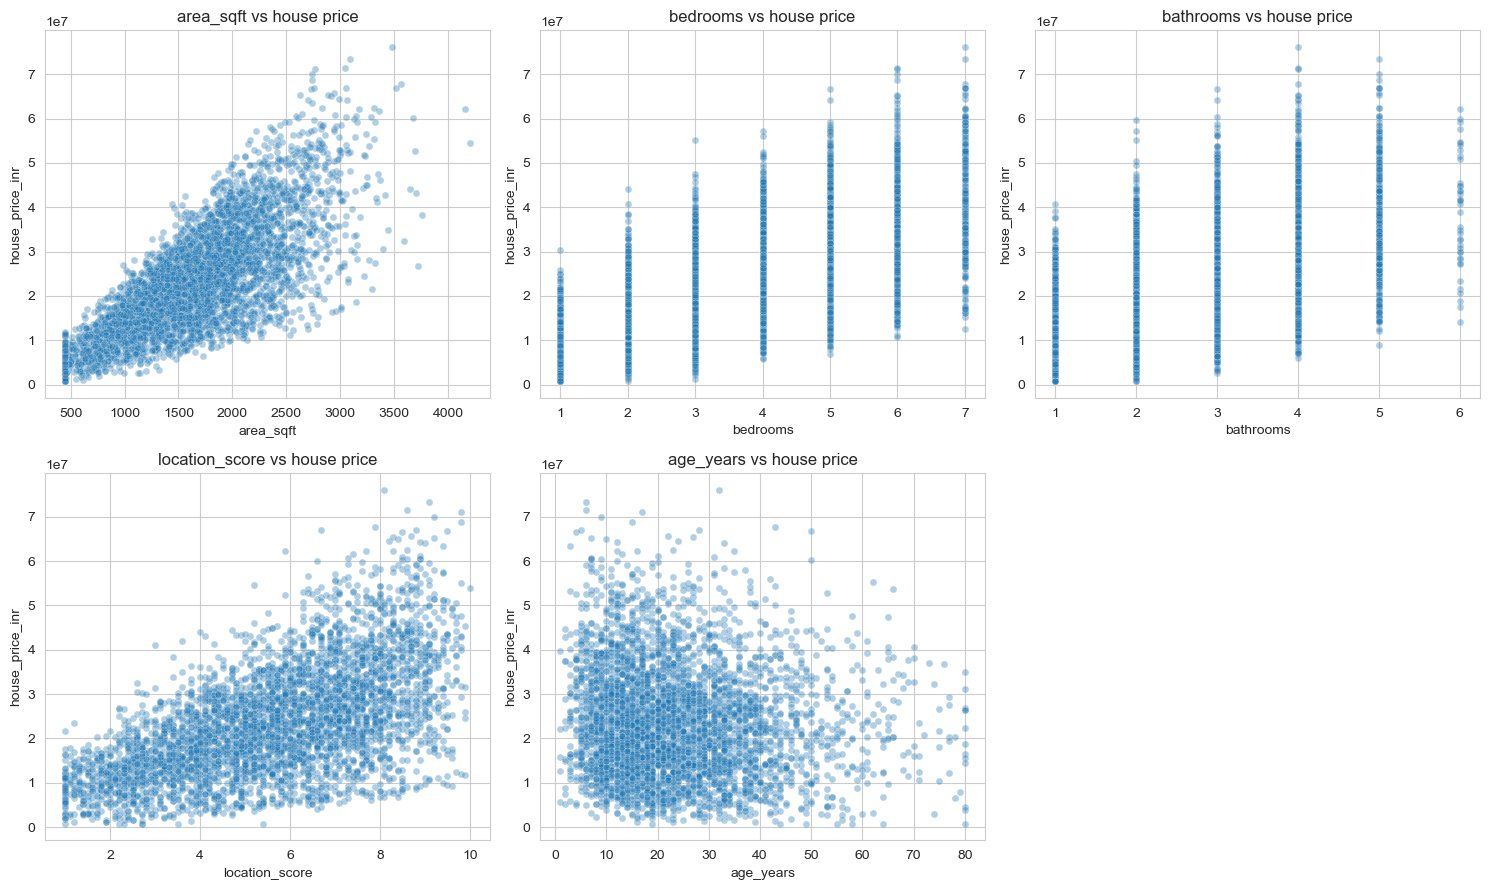

Quick note: area_sqft has the strongest positive relationship among the core variables.


In [20]:
correlation_with_target = (
    df[core_features + [target]]
    .corr(numeric_only=True)[target]
    .sort_values(ascending=False)
    .to_frame("Correlation with house price")
)
display(correlation_with_target)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, feature in zip(axes, core_features):
    sns.scatterplot(data=df, x=feature, y=target, ax=ax, alpha=0.35, s=25)
    ax.set_title(f"{feature} vs house price")

for ax in axes[len(core_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Quick note: area_sqft has the strongest positive relationship among the core variables.")

In [21]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

X_train_simple = train_df[["area_sqft"]]
X_test_simple = test_df[["area_sqft"]]

X_train_multiple = train_df[all_features]
X_test_multiple = test_df[all_features]

y_train = train_df[target]
y_test = test_df[target]

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training set shape: (3360, 12)
Testing set shape: (840, 12)
Training rows: 3360
Testing rows: 840


## Part C: Simple Linear Regression

In [22]:
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

simple_train_pred = simple_model.predict(X_train_simple)
simple_test_pred = simple_model.predict(X_test_simple)

slope = simple_model.coef_[0]
intercept = simple_model.intercept_

print(f"Simple regression equation: house_price_inr = {slope:,.2f} * area_sqft + {intercept:,.2f}")

Simple regression equation: house_price_inr = 14,788.31 * area_sqft + -1,163,519.18


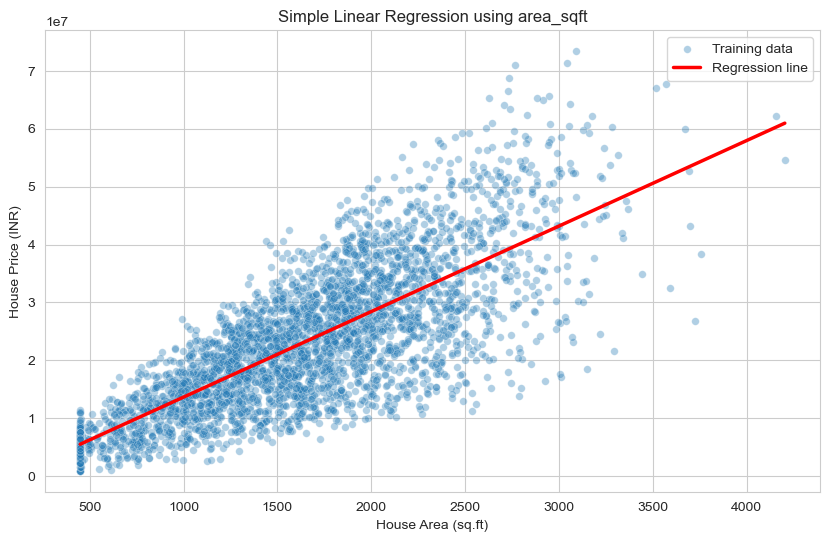

Slope interpretation: for every extra 1 sq.ft, the predicted price increases by about Rs. 14,788.31.
Intercept interpretation: when area is 0, the predicted price is Rs. -1,163,519.18.


In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_simple["area_sqft"], y=y_train, alpha=0.35, s=30, label="Training data")

line_x = np.linspace(df["area_sqft"].min(), df["area_sqft"].max(), 200)
line_y = simple_model.predict(pd.DataFrame({"area_sqft": line_x}))

plt.plot(line_x, line_y, color="red", linewidth=2.5, label="Regression line")
plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price (INR)")
plt.title("Simple Linear Regression using area_sqft")
plt.legend()
plt.show()

print(f"Slope interpretation: for every extra 1 sq.ft, the predicted price increases by about Rs. {slope:,.2f}.")
print(f"Intercept interpretation: when area is 0, the predicted price is Rs. {intercept:,.2f}.")

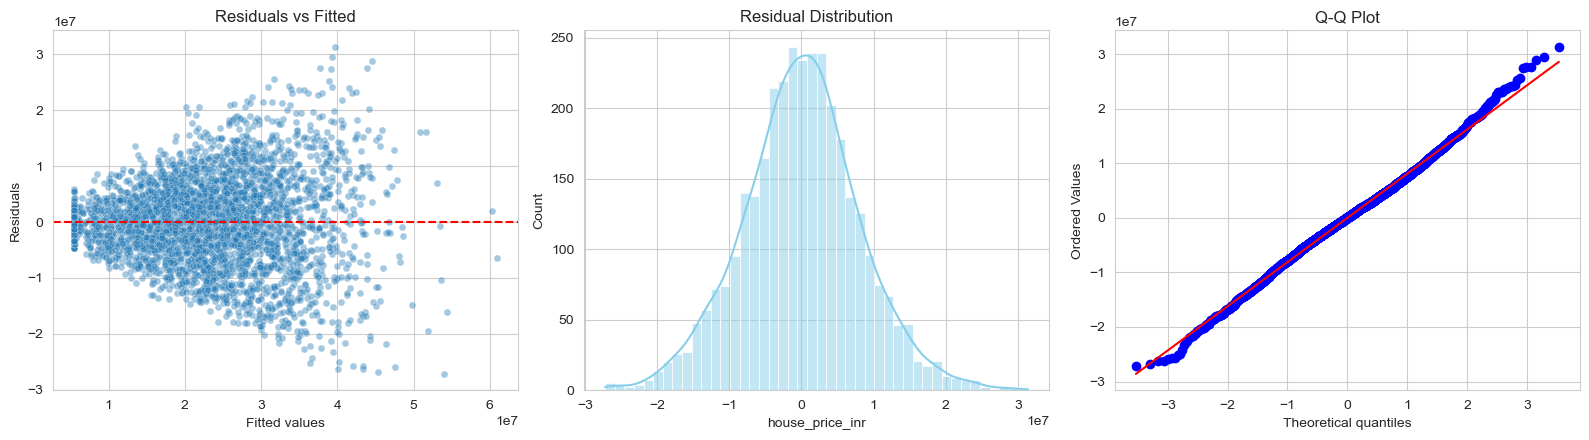

Observation:
- The residuals stay around zero, so the line captures the main direction.
- The spread is still wide, which means area alone does not explain price fully.
- Normality looks acceptable overall, but some tail deviation is present.


In [24]:
simple_residuals = y_train - simple_train_pred

plt.figure(figsize=(16, 4.5))

plt.subplot(1, 3, 1)
sns.scatterplot(x=simple_train_pred, y=simple_residuals, alpha=0.4, s=25)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

plt.subplot(1, 3, 2)
sns.histplot(simple_residuals, kde=True, color="skyblue")
plt.title("Residual Distribution")

plt.subplot(1, 3, 3)
stats.probplot(simple_residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")

plt.tight_layout()
plt.show()

print("Observation:")
print("- The residuals stay around zero, so the line captures the main direction.")
print("- The spread is still wide, which means area alone does not explain price fully.")
print("- Normality looks acceptable overall, but some tail deviation is present.")

## Part D: Model Evaluation Metrics

In [25]:
simple_train_metrics = regression_metrics(y_train, simple_train_pred, 1)
simple_test_metrics = regression_metrics(y_test, simple_test_pred, 1)

simple_metrics_table = pd.DataFrame(
    [simple_train_metrics, simple_test_metrics],
    index=["Train", "Test"]
)

display(simple_metrics_table.round(4))

,MSE,MAE,RMSE,R2 Score,Adjusted R2
Train,6.568175e+13,6.291402e+06,8.104428e+06,0.5723,0.5722
Test,6.698926e+13,6.294594e+06,8.184697e+06,0.5625,0.5620


### 14. Interpretation of the Evaluation Metrics
- `MSE` and `RMSE` are still high, so the prediction errors are large in rupee terms.
- `MAE` shows the average absolute gap between the actual price and predicted price.
- `R2 Score` around the mid-range means area alone explains only part of the price variation.
- `Adjusted R2` is almost the same here because only one predictor is used.
- Overall, the simple model gives a rough estimate but it is not a strong final model.

## Part E: Multiple Linear Regression

In [26]:
multiple_model = LinearRegression()
multiple_model.fit(X_train_multiple, y_train)

multiple_train_pred = multiple_model.predict(X_train_multiple)
multiple_test_pred = multiple_model.predict(X_test_multiple)

multiple_train_metrics = regression_metrics(y_train, multiple_train_pred, len(all_features))
multiple_test_metrics = regression_metrics(y_test, multiple_test_pred, len(all_features))

multiple_metrics_table = pd.DataFrame(
    [multiple_train_metrics, multiple_test_metrics],
    index=["Train", "Test"]
)
display(multiple_metrics_table.round(4))

coefficient_table = (
    pd.DataFrame({"Feature": all_features, "Coefficient": multiple_model.coef_})
    .sort_values("Coefficient", key=np.abs, ascending=False)
    .reset_index(drop=True)
)
display(coefficient_table)

,MSE,MAE,RMSE,R2 Score,Adjusted R2
Train,1.156067e+13,2.563797e+06,3.400099e+06,0.9247,0.9245
Test,1.259292e+13,2.604991e+06,3.548650e+06,0.9178,0.9168


,Feature,Coefficient
0,location_score,3.073174e+06
1,has_pool,4.552902e+05
2,bedrooms,1.976431e+05
3,bathrooms,1.859445e+05
4,distance_city_km,-9.896516e+04
5,has_garage,9.392436e+04
6,age_years,-6.560924e+04
7,renovation_years_ago,-2.143591e+04
8,area_sqft,1.379594e+04
9,lot_size_sqft,1.035058e+02


In [27]:
comparison_df = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "Test MAE": [simple_test_metrics["MAE"], multiple_test_metrics["MAE"]],
    "Test RMSE": [simple_test_metrics["RMSE"], multiple_test_metrics["RMSE"]],
    "Test R2": [simple_test_metrics["R2 Score"], multiple_test_metrics["R2 Score"]],
    "Test Adjusted R2": [simple_test_metrics["Adjusted R2"], multiple_test_metrics["Adjusted R2"]],
})

display(comparison_df.round(4))

rmse_improvement = (
    (simple_test_metrics["RMSE"] - multiple_test_metrics["RMSE"])
    / simple_test_metrics["RMSE"]
    * 100
)

print(f"RMSE dropped by about {rmse_improvement:.2f}% after using multiple features.")

,Model,Test MAE,Test RMSE,Test R2,Test Adjusted R2
0,Simple Linear Regression,6.294594e+06,8.184697e+06,0.5625,0.5620
1,Multiple Linear Regression,2.604991e+06,3.548650e+06,0.9178,0.9168


RMSE dropped by about 56.64% after using multiple features.


### 17. Why the Performance Improves or Degrades
Multiple linear regression performs much better because house price depends on more than area. Features like location score, number of rooms, age, distance from the city, and amenities add useful information. The model improves because it sees more of the real pricing factors instead of forcing everything through one variable.

## Part F: Polynomial Regression

In [28]:
poly_results = []
poly_models = {}

for degree in [2, 3]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear", LinearRegression()),
    ])
    model.fit(X_train_simple, y_train)

    train_pred = model.predict(X_train_simple)
    test_pred = model.predict(X_test_simple)

    feature_count = model.named_steps["poly"].n_output_features_

    poly_results.append({
        "Degree": degree,
        "Train RMSE": mean_squared_error(y_train, train_pred) ** 0.5,
        "Test RMSE": mean_squared_error(y_test, test_pred) ** 0.5,
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
        "Train Adjusted R2": adjusted_r2(r2_score(y_train, train_pred), len(y_train), feature_count),
        "Test Adjusted R2": adjusted_r2(r2_score(y_test, test_pred), len(y_test), feature_count),
    })

    poly_models[degree] = model

poly_results_df = pd.DataFrame(poly_results)
display(poly_results_df.round(4))

best_poly_degree = int(poly_results_df.sort_values("Test R2", ascending=False).iloc[0]["Degree"])
print(f"Best polynomial degree on the test set: {best_poly_degree}")

,Degree,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2
0,2,8.102913e+06,8.183089e+06,0.5725,0.5627,0.5722,0.5616
1,3,8.101891e+06,8.181382e+06,0.5726,0.5629,0.5722,0.5613


Best polynomial degree on the test set: 3


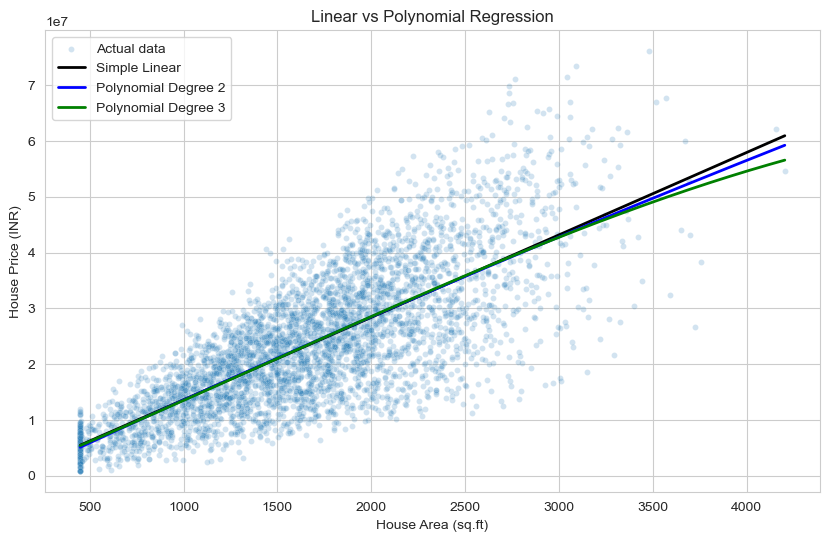

,Model,Test RMSE,Test R2
0,Simple Linear,8.184697e+06,0.5625
1,Polynomial Degree 2,8.183089e+06,0.5627
2,Polynomial Degree 3,8.181382e+06,0.5629


In [29]:
comparison_curve = np.linspace(df["area_sqft"].min(), df["area_sqft"].max(), 300)
comparison_frame = pd.DataFrame({"area_sqft": comparison_curve})

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["area_sqft"], y=df[target], alpha=0.2, s=18, label="Actual data")
plt.plot(comparison_curve, simple_model.predict(comparison_frame), color="black", linewidth=2, label="Simple Linear")
plt.plot(comparison_curve, poly_models[2].predict(comparison_frame), color="blue", linewidth=2, label="Polynomial Degree 2")
plt.plot(comparison_curve, poly_models[3].predict(comparison_frame), color="green", linewidth=2, label="Polynomial Degree 3")
plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price (INR)")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

poly_compare_df = pd.DataFrame({
    "Model": ["Simple Linear", "Polynomial Degree 2", "Polynomial Degree 3"],
    "Test RMSE": [
        simple_test_metrics["RMSE"],
        poly_results_df.loc[poly_results_df["Degree"] == 2, "Test RMSE"].iloc[0],
        poly_results_df.loc[poly_results_df["Degree"] == 3, "Test RMSE"].iloc[0],
    ],
    "Test R2": [
        simple_test_metrics["R2 Score"],
        poly_results_df.loc[poly_results_df["Degree"] == 2, "Test R2"].iloc[0],
        poly_results_df.loc[poly_results_df["Degree"] == 3, "Test R2"].iloc[0],
    ],
})
display(poly_compare_df.round(4))

### 20. Signs of Overfitting or Underfitting
The polynomial models give only a very small improvement over the simple straight-line model. That means there is no strong sign of heavy overfitting here because test performance does not collapse. At the same time, all one-feature models still underfit because area alone cannot capture the full pricing pattern.

## Part G: Gradient Descent Optimization

### 21. Explain Gradient Descent Conceptually
Gradient descent is an optimization method that updates model weights step by step to reduce error. In each step, it moves in the opposite direction of the gradient because that is the direction of fastest decrease. Batch uses all rows at once, SGD uses one row at a time, and mini-batch uses small groups of rows.

In [30]:
X_train_gd = train_df[all_features].values.astype(float)
X_test_gd = test_df[all_features].values.astype(float)
y_train_gd = train_df[target].values.astype(float).reshape(-1, 1)
y_test_gd = test_df[target].values.astype(float).reshape(-1, 1)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_gd_scaled = x_scaler.fit_transform(X_train_gd)
X_test_gd_scaled = x_scaler.transform(X_test_gd)
y_train_gd_scaled = y_scaler.fit_transform(y_train_gd)

X_train_gd_bias = np.c_[np.ones((X_train_gd_scaled.shape[0], 1)), X_train_gd_scaled]
X_test_gd_bias = np.c_[np.ones((X_test_gd_scaled.shape[0], 1)), X_test_gd_scaled]

def mse_loss(X, y, weights):
    errors = X @ weights - y
    return float(np.mean(errors ** 2))

def evaluate_gd_run(label, weights, losses, elapsed_time):
    test_pred = y_scaler.inverse_transform(X_test_gd_bias @ weights).ravel()
    return {
        "Model": label,
        "Time (seconds)": elapsed_time,
        "Start Loss": losses[0],
        "End Loss": losses[-1],
        "Test RMSE": mean_squared_error(y_test_gd.ravel(), test_pred) ** 0.5,
        "Test R2": r2_score(y_test_gd.ravel(), test_pred),
    }

def batch_gradient_descent(X, y, learning_rate=0.05, epochs=400):
    row_count, feature_count = X.shape
    weights = np.zeros((feature_count, 1))
    losses = []
    start_time = time.perf_counter()

    for _ in range(epochs):
        gradients = (2 / row_count) * X.T @ (X @ weights - y)
        weights -= learning_rate * gradients
        losses.append(mse_loss(X, y, weights))

    elapsed_time = time.perf_counter() - start_time
    return weights, losses, elapsed_time

batch_weights, batch_losses, batch_time = batch_gradient_descent(X_train_gd_bias, y_train_gd_scaled)

gd_summary = []
gd_summary.append(
    evaluate_gd_run("Batch Gradient Descent", batch_weights, batch_losses, batch_time)
)

print("Batch gradient descent finished.")
print("Starting loss:", round(batch_losses[0], 6))
print("Ending loss:", round(batch_losses[-1], 6))

Batch gradient descent finished.
Starting loss: 0.618192
Ending loss: 0.07528


In [31]:
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=25, seed=42):
    row_count, feature_count = X.shape
    weights = np.zeros((feature_count, 1))
    losses = []
    rng = np.random.default_rng(seed)
    start_time = time.perf_counter()

    for _ in range(epochs):
        shuffled_index = rng.permutation(row_count)
        for index in shuffled_index:
            x_row = X[index:index + 1]
            y_row = y[index:index + 1]
            gradients = 2 * x_row.T @ (x_row @ weights - y_row)
            weights -= learning_rate * gradients
        losses.append(mse_loss(X, y, weights))

    elapsed_time = time.perf_counter() - start_time
    return weights, losses, elapsed_time

sgd_weights, sgd_losses, sgd_time = stochastic_gradient_descent(X_train_gd_bias, y_train_gd_scaled)

gd_summary.append(
    evaluate_gd_run("Stochastic Gradient Descent", sgd_weights, sgd_losses, sgd_time)
)

print("Stochastic gradient descent finished.")
print("Starting loss:", round(sgd_losses[0], 6))
print("Ending loss:", round(sgd_losses[-1], 6))

Stochastic gradient descent finished.
Starting loss: 0.092622
Ending loss: 0.087172


In [32]:
def mini_batch_gradient_descent(X, y, learning_rate=0.03, epochs=120, batch_size=32, seed=42):
    row_count, feature_count = X.shape
    weights = np.zeros((feature_count, 1))
    losses = []
    rng = np.random.default_rng(seed)
    start_time = time.perf_counter()

    for _ in range(epochs):
        shuffled_index = rng.permutation(row_count)
        X_shuffled = X[shuffled_index]
        y_shuffled = y[shuffled_index]

        for start_index in range(0, row_count, batch_size):
            X_batch = X_shuffled[start_index:start_index + batch_size]
            y_batch = y_shuffled[start_index:start_index + batch_size]
            gradients = (2 / len(X_batch)) * X_batch.T @ (X_batch @ weights - y_batch)
            weights -= learning_rate * gradients

        losses.append(mse_loss(X, y, weights))

    elapsed_time = time.perf_counter() - start_time
    return weights, losses, elapsed_time

mini_batch_weights, mini_batch_losses, mini_batch_time = mini_batch_gradient_descent(
    X_train_gd_bias,
    y_train_gd_scaled
)

gd_summary.append(
    evaluate_gd_run("Mini-Batch Gradient Descent", mini_batch_weights, mini_batch_losses, mini_batch_time)
)

print("Mini-batch gradient descent finished.")
print("Starting loss:", round(mini_batch_losses[0], 6))
print("Ending loss:", round(mini_batch_losses[-1], 6))

Mini-batch gradient descent finished.
Starting loss: 0.084593
Ending loss: 0.075815


,Model,Time (seconds),Start Loss,End Loss,Test RMSE,Test R2
0,Batch Gradient Descent,0.0732,0.6182,0.0753,3.549170e+06,0.9177
1,Stochastic Gradient Descent,0.7773,0.0926,0.0872,3.812852e+06,0.9051
2,Mini-Batch Gradient Descent,0.0940,0.0846,0.0758,3.568165e+06,0.9169


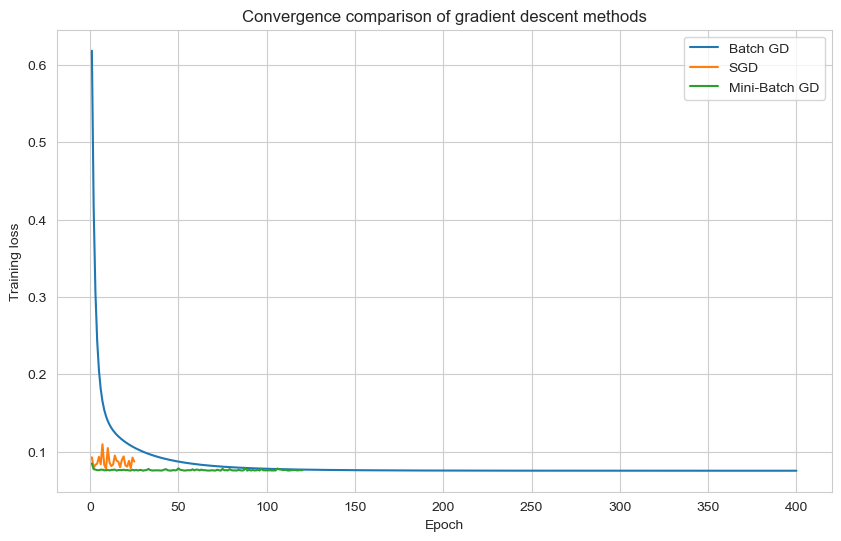

Observation:
- Batch GD gives smooth convergence and strong final accuracy.
- SGD learns with noisier updates and a slightly weaker final score.
- Mini-batch GD is also fast and performs close to batch GD.


In [33]:
gd_results_df = pd.DataFrame(gd_summary)
display(gd_results_df.round(4))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(batch_losses) + 1), batch_losses, label="Batch GD")
plt.plot(range(1, len(sgd_losses) + 1), sgd_losses, label="SGD")
plt.plot(range(1, len(mini_batch_losses) + 1), mini_batch_losses, label="Mini-Batch GD")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Convergence comparison of gradient descent methods")
plt.legend()
plt.show()

print("Observation:")
print("- Batch GD gives smooth convergence and strong final accuracy.")
print("- SGD learns with noisier updates and a slightly weaker final score.")
print("- Mini-batch GD is also fast and performs close to batch GD.")

## Part H: Bias-Variance and Model Diagnostics

In [34]:
best_poly_row = poly_results_df.sort_values("Test R2", ascending=False).iloc[0]

bias_variance_df = pd.DataFrame([
    {
        "Model": "Simple Linear Regression",
        "Train R2": simple_train_metrics["R2 Score"],
        "Test R2": simple_test_metrics["R2 Score"],
        "R2 Gap": simple_train_metrics["R2 Score"] - simple_test_metrics["R2 Score"],
        "Reading": "High bias, low variance",
    },
    {
        "Model": "Multiple Linear Regression",
        "Train R2": multiple_train_metrics["R2 Score"],
        "Test R2": multiple_test_metrics["R2 Score"],
        "R2 Gap": multiple_train_metrics["R2 Score"] - multiple_test_metrics["R2 Score"],
        "Reading": "Low bias, controlled variance",
    },
    {
        "Model": f"Polynomial Regression (Degree {int(best_poly_row['Degree'])})",
        "Train R2": float(best_poly_row["Train R2"]),
        "Test R2": float(best_poly_row["Test R2"]),
        "R2 Gap": float(best_poly_row["Train R2"] - best_poly_row["Test R2"]),
        "Reading": "Slightly lower bias than simple, but still limited",
    },
])

display(bias_variance_df.round(4))

,Model,Train R2,Test R2,R2 Gap,Reading
0,Simple Linear Regression,0.5723,0.5625,0.0098,"High bias, low variance"
1,Multiple Linear Regression,0.9247,0.9178,0.0070,"Low bias, controlled variance"
2,Polynomial Regression (Degree 3),0.5726,0.5629,0.0097,"Slightly lower bias than simple, but still lim..."


### 27. How Model Complexity Affects Prediction Error
As model complexity increases from simple linear to multiple linear regression, bias usually drops because the model can learn more of the real pattern. But if complexity keeps increasing without enough useful information, variance can rise and test performance may stop improving. So the aim is not the most complex model, but the one with the lowest test error and stable generalization.

### 28. Model that Best Balances Bias and Variance
For this dataset, multiple linear regression gives the best balance of bias and variance. It has the highest test `R2` and much lower error than the one-feature models, while the train-test gap stays small. So it generalizes better without showing clear overfitting.

## Part I: Final Analysis and Reporting

### 29. Final Report
- Best-performing model: Multiple Linear Regression. It works best because house prices depend on several features, not only area.
- Impact of gradient descent: Batch and mini-batch converged well after scaling. SGD also worked, but its path was noisier and its final score was slightly lower.
- Evidence of overfitting or underfitting: The simple and polynomial one-feature models still underfit. I did not observe strong overfitting in the final multiple linear regression model.
- Practical business meaning: Price usually increases with better location, larger area, more rooms, and useful amenities. Distance from city and age of property generally reduce price, which matches normal real-estate behavior.